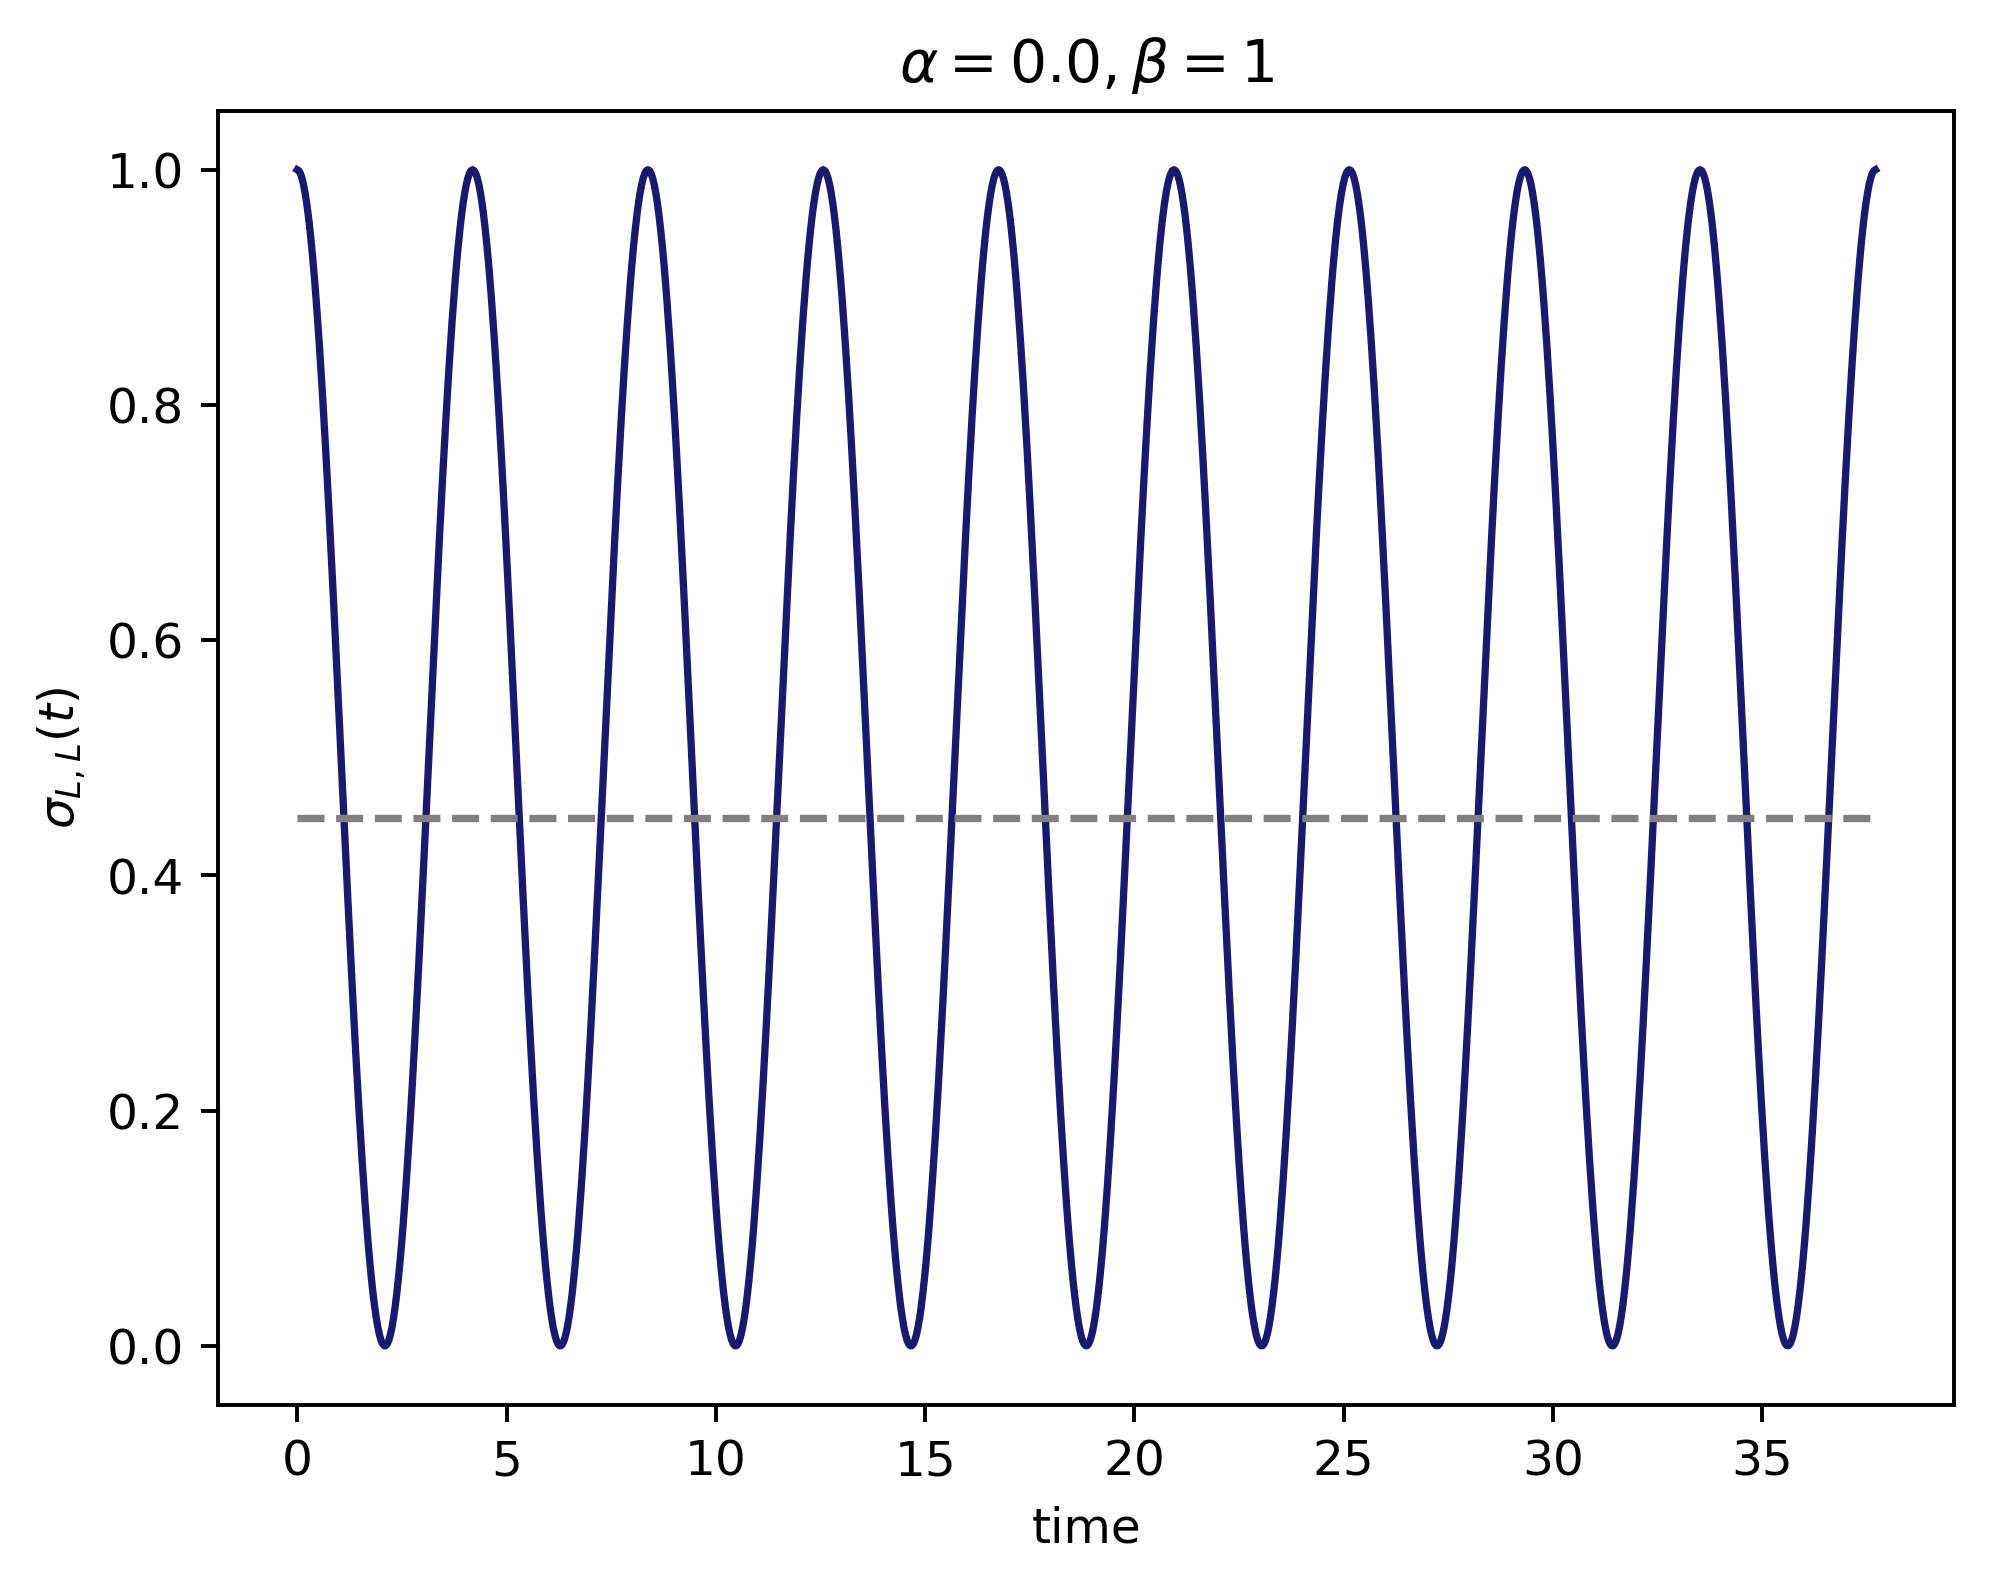

In [2]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt
from scipy.linalg import expm
plt.rcParams['figure.dpi']=350

#parameters
w_c=20
Delta=1
alpha=0.0 #pick from {0,0.05,0.1,0.2}
beta=1  #pick from {0.5,1,2}


def J(w): #define J(w) with dependancy on alpha
    return 2*alpha*w*np.exp(-w/w_c)

def eta(w): #define eta(w) with dependancy on beta
    return 1/(np.exp(beta*w)-1)
K_12=(np.pi/2)*J(Delta)*eta(Delta) #E_21=Delta
K_21=(np.pi/2)*J(Delta)*(eta(Delta)+1)
s=0.5*(K_12+K_21)

#define cob matrix for vectorised RDM (sigma in LR to sigma in 12)
R=(1/2)*np.array([[1,1,1,1],
                 [1,-1,1,-1],
                 [1,1,-1,-1],
                 [1,-1,-1,1]]) #note R^-1=R
#time evolution matrix for sigma in 12 basis
A=np.array([[-K_12,0,0,K_21],
            [0,-Delta*1j-s, s,0],
            [0,s,Delta*1j-s,0],
            [K_12,0,0,-K_21]])

#define initial condition in LR basis
sigma0=zeros(2,2)
sigma0[0,0]=1 #|L> is occupied
sigma0_vec=np.array(sigma0.T.reshape(4, 1),dtype=complex) #vectorised DM in LR basis, column stack

times=np.linspace(0,12*np.pi,1000) #simulation time array until 6*2pi/Delta 

P_LL=[] #list to store probability sigma_LL
for t in times:
    sigma=expm(R@A@R*t)@sigma0_vec
    P_LL.append(sigma[0,0].real) #take real part due to approximations 
P_LL=np.array(P_LL)

#plot
plt.plot(times,P_LL,color='midnightblue')
plt.plot(times,np.average(P_LL[900:])*np.ones_like(P_LL),color='grey',ls='--')
plt.xlabel('time')
plt.ylabel('$\\sigma_{{L,L}}(t)$')
plt.title(f'$\\alpha={alpha},\\beta={beta}$')
plt.show()
